In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from mmtrack import pre_process_mm
from mmtrack import mm_cell_segmentation as mm3seg
from mmtrack import plot_cells
import warnings
import networkx as nx
import tifffile
from skimage.filters import threshold_otsu
import skimage.segmentation as segmentation
from skimage import segmentation, morphology, measure, filters
import scipy.ndimage as ndi
from skimage.filters import threshold_local
import json

In [44]:
csv_path = "/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/image_analysis_testing/pos_list_test/hyperstacked/drift_corrected/rotated/mm_channelsFOV021.csv"
rotated_tif_path = "/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/image_analysis_testing/pos_list_test/hyperstacked/drift_corrected/rotated/rotated_drift_cor_DuMM_xy021.tif"

In [45]:
trench_ids = pd.read_csv(csv_path)
image = tifffile.imread(rotated_tif_path)


In [46]:
phase_stack = image[:,0,:,:]
fluor_stack = image[:,1,:,:]

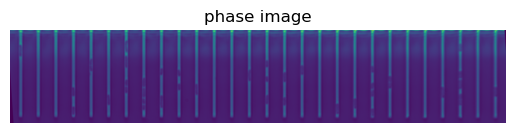

In [47]:
phase_image = phase_stack[1]
plt.figure()
plt.imshow(phase_image)
plt.title('phase image')
plt.axis('off')  # Hide axis labels
plt.draw()

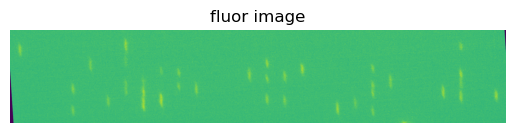

In [48]:
fluor_image = fluor_stack[1]
plt.figure()
plt.imshow(fluor_image)
plt.title('fluor image')
plt.axis('off')  # Hide axis labels
plt.draw()

In [49]:
y_length = phase_stack.shape[1]  # Number of y pixels
y_start = int(0.1 * y_length)  # Starting index (10%)
y_end = int(0.9 * y_length)  

x_length = phase_stack.shape[2]  # Number of y pixels
x_start = int(0.1 * y_length)  # Starting index (10%)
x_end = int(0.9 * y_length)  

cropped_min_val = np.min(phase_stack[:, y_start:y_end, x_start:x_end])
cropped_max_val = np.max(phase_stack[:, y_start:y_end, x_start:x_end])
if cropped_max_val > cropped_min_val:
    normalized_phase_stack = (phase_stack - cropped_min_val) / (cropped_max_val - cropped_min_val)
else:
    print("All values in phase_stack are the same. Normalization will not change the data.")

In [50]:
average_intensity = []  # Initialize a list to store results
y_length = normalized_phase_stack.shape[1]  # Number of y pixels
y_start = int(0.1 * y_length)  # Starting index (10%)
y_end = int(0.9 * y_length)    # Ending index (90%)

for idx, row in trench_ids.iterrows():
    trench = row[0]  # Assuming the trench ID is the first column
    x = row[1]       # Assuming the x coordinate is the second column
    
    if 0 <= x < normalized_phase_stack.shape[2]:
        intensity_values = normalized_phase_stack[:, :, x+6]  # Extract values for the channel x
        intensity_values_middle = intensity_values[:, y_start:y_end]
        avg_int = np.min(intensity_values_middle, axis=0)  # Average over time
        
        final_avg_intensity = np.mean(avg_int)  # Further average over y dimension
        average_intensity.append((trench, final_avg_intensity))  # Store trench and avg intensity
    else:
        average_intensity.append((trench, None))  # Append None for out-of-bounds trench

# Convert results to a DataFrame
results_df = pd.DataFrame(average_intensity, columns=['trench_id', 'avg_int'])  # Store trench_id instead of channel_id

# Step 4: Determine empty and non-empty trenches based on a threshold
threshold = 0.25  # Example threshold (adjust as necessary)

results_df['is_empty'] = results_df['avg_int'].apply(lambda x: x is None or x < threshold)

#Display results
print(results_df)

    trench_id   avg_int  is_empty
0          46  0.226023      True
1         121  0.439821     False
2         197  0.470350     False
3         272  0.181252      True
4         348  0.315805     False
5         423  0.431392     False
6         498  0.181227      True
7         574  0.167566      True
8         649  0.177228      True
9         724  0.196510      True
10        800  0.433348     False
11        875  0.487149     False
12        950  0.460997     False
13       1026  0.272249     False
14       1101  0.277783     False
15       1176  0.286926     False
16       1252  0.389787     False
17       1327  0.488604     False
18       1402  0.228251      True
19       1478  0.432647     False
20       1553  0.239346      True
21       1628  0.294228     False
22       1704  0.488726     False
23       1779  0.450726     False
24       1854  0.301141     False
25       1930  0.227310      True
26       2005  0.426178     False
27       2081  0.328224     False


/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_26554/853471297.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  trench = row[0]  # Assuming the trench ID is the first column
/var/folders/z0/t_qxft797x97j_j_sdkjdv740000gn/T/ipykernel_26554/853471297.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = row[1]       # Assuming the x coordinate is the second column


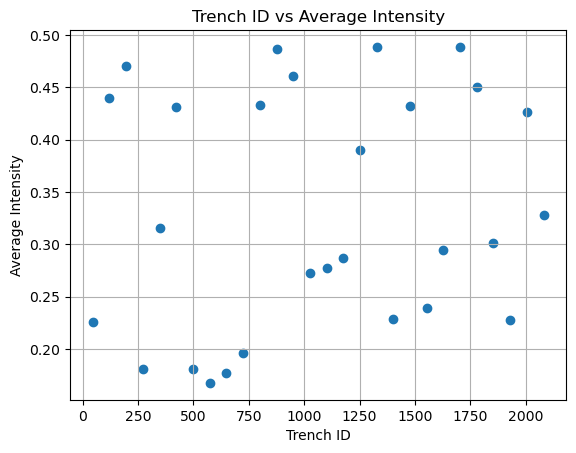

In [51]:
filtered_results = results_df[results_df['avg_int'].notna()]
plt.scatter(results_df['trench_id'], filtered_results['avg_int'])

plt.title('Trench ID vs Average Intensity')
plt.xlabel('Trench ID')
plt.ylabel('Average Intensity')
plt.grid(True)

### TODO
5. function can be used in jupyter notebook with copy and paste paths or using select file from OS package to make it easier to use in juptyer notebook
6. output should be ana peak ids in JSON format so code will need to be able to take in more than one FOV and CSV and be able to parse file names to match correct FOVs